<a href="https://colab.research.google.com/github/raphaelferreiravieira/Trabalho-Final/blob/main/Trab_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score


**Importando arquivo do tipo csv considerando a opcao A para realizacao do trabalho final utilizando a funcao read_csv do pandas e transformando o dado em um tipo de dado DataFrame**


In [ ]:
df=pd.read_csv("credit_risk_dataset.csv")

A observacao da base de dados revela as seguintes colunas:

**person_age (Idade)**: Idade do cliente em anos;

**person_income (Rendimento Anual)**: Rendimento anual bruto do cliente por ano;

**person_home_ownership (Situação Habitacional)**: Tipo de posse de habitação do proponente, dividida em quatro categorias: RENT (Arrendado), MORTGAGE (Hipoteca/Crédito habitação), OWN (Casa própria) e OTHER (Outro);

**person_emp_length (Tempo de Emprego)**: Tempo de serviço ou experiência de trabalho do cliente em anos;

**loan_intent (Finalidade do Empréstimo)**: O motivo do pedido do empréstimo, classificado em seis categorias: Pessoal, Educação, Saúde, Negócios/Empreendedorismo, Obras/Remodelação e Consolidação de dívida;

**loan_grade (Classificação do Empréstimo):** Categoria de risco atribuída ao crédito pelo sistema de scoring, numa escala de A (menor risco) a G (maior risco);

**loan_amnt (Montante do Empréstimo): **Valor total do empréstimo solicitado pelo cliente em unidades monetarias;

**loan_int_rate (Taxa de Juro)**: Taxa de juro anual do empréstimo em percentagem;

**loan_percent_income**: Proporção do valor do empréstimo em relação ao rendimento anual do cliente;

**cb_person_default_on_file**: Indica se o cliente tem um histórico prévio de nao cumprimento/falha de pagamento;

**cb_person_cred_hist_length**: Anos de histórico de crédito registados no bureau desde a abertura da primeira conta/crédito do cliente, variando entre 2 e 30 anos.

**Apos a importacao de dados e necessario realizar a sua analise exploratoria de dados (EDA)-FASE 1**

**1. Primeiramente sera visualizado a quantidade de linhas e colunas do dado utilizando shape conforme descrito abaixo. Ao realizar o print verifica-se que o dado contem 32581 linhas e 12 colunas.**

In [ ]:
print(f'O dado contem {df.shape[0]} linhas e {df.shape[1]} colunas')

O dado contem 32581 linhas e 12 colunas


**2. Apos isso optou-se por descrever o tipo de dado de cada coluna por meio da funcao info do pandas. A informacao da funcao info revela que existem dados nulos (vazios) em algumas variveis como loan_int_rate e person_emp_length e que os principais tipos de dados sao int64, float64 e object**

In [ ]:
df. info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [ ]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [ ]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


**Variavel alvo para essa base de dados e uma variavel binaria que indicara se o cliente cumpriu ou nao cumpriu o pagamento (loan_status)**

Em caso de 0 o cliente cumpriu o pagamento dentro do prazo e em caso de 1 o cliente esta inadimplente. Abaixo sera plotado um grafico indicando o percentual de casos com 0 e com 1 da base de dados escolhida.

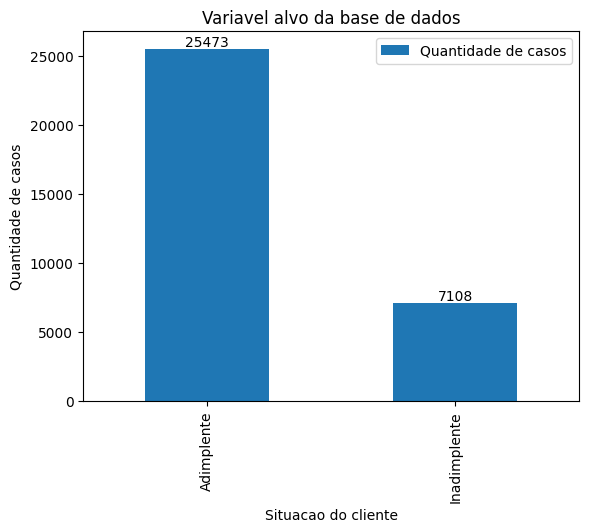

<Axes: title={'center': 'Variavel alvo da base de dados'}, xlabel='Situacao do cliente', ylabel='Quantidade de casos'>

In [ ]:
valores_target=df['loan_status'].value_counts().plot(kind='bar', legend=True)
plt.xticks([0,1],['Adimplente','Inadimplente'])
plt.legend(['Quantidade de casos'])
plt.title ('Variavel alvo da base de dados')
plt.xlabel('Situacao do cliente')
plt.ylabel('Quantidade de casos')
plt.bar_label(plt.gca().containers[0])
plt.show()
valores_target

**Observa-se um desbalanceamento moderado tendo em vista que a condicao de pagamento adimplente e quase 4 vezes maior em quantidade de dados que a condicao de inadimplente.**

In [ ]:
coluna_numer=df.select_dtypes(include=['float','int']).columns.tolist()
correlacao=df[coluna_numer].corr()
correlacao

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
person_age,1.000000,0.173202,0.163106,0.050787,0.012580,-0.021629,-0.042411,0.859133
person_income,0.173202,1.000000,0.134268,0.266820,0.000792,-0.144449,-0.254471,0.117987
person_emp_length,0.163106,0.134268,1.000000,0.113082,-0.056405,-0.082489,-0.054111,0.144699
loan_amnt,0.050787,0.266820,0.113082,1.000000,0.146813,0.105376,0.572612,0.041967
loan_int_rate,0.012580,0.000792,-0.056405,0.146813,1.000000,0.335133,0.120314,0.016696
loan_status,-0.021629,-0.144449,-0.082489,0.105376,0.335133,1.000000,0.379366,-0.015529
loan_percent_income,-0.042411,-0.254471,-0.054111,0.572612,0.120314,0.379366,1.000000,-0.031690
cb_person_cred_hist_length,0.859133,0.117987,0.144699,0.041967,0.016696,-0.015529,-0.031690,1.000000


<Axes: >

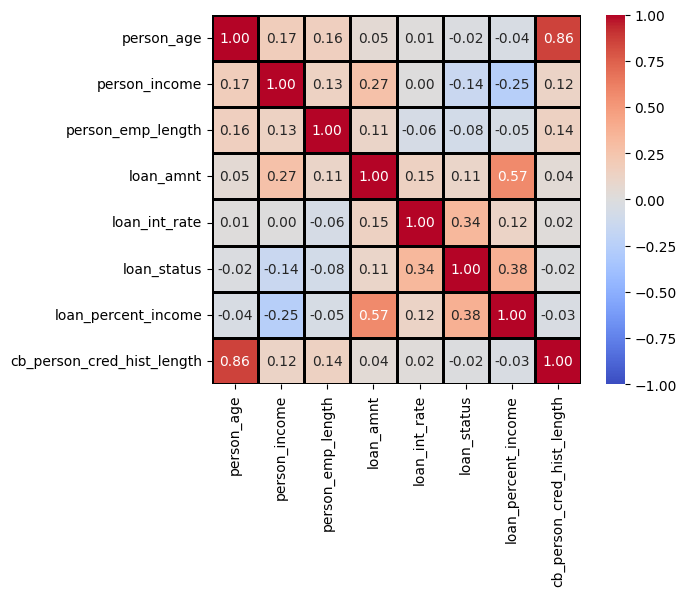

In [ ]:
sns.heatmap(data=correlacao, annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    linewidths=1,
    linecolor="black",
    square=True,
    cbar=True,  )

**A analise da correlacao revela que:**


loan_percent_income	+0,38: Quanto mais o rendimento e comprometido com o emprestimo maior a probabilidade de inadimplencia.

loan_int_rate	+0,34: Quanto maior a taxa de juros, maior a probabilidade do cliente ficar inadimplente.

person_income	-0,14 : Maiores rendimento diminiuem a probabilidade de inadimplencia.

loan_amnt	+0,11	: Imprestimos maiores aumentam o risco da inadimplencia.

person_emp_length	-0,08: Maior estabilidade no emprego, menor risco de inadimplencia.

person_age	-0,02: Sem correlacao significativa

cb_person_cred_hist_length	-0,02: Sem correlacao significativa